In [9]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import networkx as nx
import scipy.sparse as sp
import itertools
from collections import defaultdict
from joblib import Parallel, delayed

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.dummy import DummyClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, make_scorer, roc_auc_score
from sklearn.decomposition import PCA

In [10]:
epi = pd.read_csv('epinions.txt', sep = '\t', names = ['FromNodeId','ToNodeId','Sign'], skiprows=4)
epi.head()

,FromNodeId,ToNodeId,Sign
0,0,1,-1
1,1,128552,-1
2,2,3,1
3,4,5,-1
4,4,155,-1


In [11]:
G_epi = nx.from_pandas_edgelist(epi, source='FromNodeId', target='ToNodeId', edge_attr='Sign', create_using=nx.DiGraph())

print(f"El grafo tiene {G_epi.number_of_nodes()} nodos y {G_epi.number_of_edges()} aristas.")

El grafo tiene 131828 nodos y 841372 aristas.


# Grado 2:

In [12]:
import numpy as np
import pandas as pd
from tqdm import tqdm
from collections import defaultdict
from joblib import Parallel, delayed

# =====================================================================
# 1. FUNCIÓN AYUDANTE
# =====================================================================
def extraer_signo(atributo):
    if isinstance(atributo, dict):
        return atributo.get('Sign', 1)
    return atributo if atributo is not None else 1

# =====================================================================
# 2. FUNCIÓN TRABAJADORA
# =====================================================================
def procesar_lote(batch_u, edges_dict_batch, node_idx, dout_p, dout_m, din_p, din_m, neighbors):

    rows_by_uv = []

    for u in batch_u:
        u_idx = node_idx[u]
        neigh_u = neighbors[u]

        for v, sign in edges_dict_batch[u]:
            v_idx = node_idx[v]

            # Embeddedness = número de vecinos comunes entre u y v
            embeddedness_uv = len(neigh_u.intersection(neighbors[v]))

            row = {
                'sign': sign,
                'dout_pos_u': dout_p[u_idx],
                'dout_neg_u': dout_m[u_idx],
                'din_pos_v': din_p[v_idx],
                'din_neg_v': din_m[v_idx],
                'total_out_u': dout_p[u_idx] + dout_m[u_idx],
                'total_in_v': din_p[v_idx] + din_m[v_idx],
                'embeddedness': embeddedness_uv
            }

            rows_by_uv.append(row)

    return rows_by_uv


# =====================================================================
# 3. FUNCIÓN ORQUESTADORA
# =====================================================================
def generar_dataset_features2(G, edges_to_process=None, batch_size=50, n_jobs=-1):

    nodes = list(G.nodes())
    node_idx = {node: i for i, node in enumerate(nodes)}
    num_nodes = len(nodes)

    dout_p = np.zeros(num_nodes, dtype=np.int32)
    dout_m = np.zeros(num_nodes, dtype=np.int32)
    din_p = np.zeros(num_nodes, dtype=np.int32)
    din_m = np.zeros(num_nodes, dtype=np.int32)

    # ================================================================
    # 1/3 Calcular grados positivos y negativos
    # ================================================================
    for u, v, data in tqdm(G.edges(data=True), desc="1/3 Calculando grados"):

        sign = int(extraer_signo(data))

        i = node_idx[u]
        j = node_idx[v]

        if sign == 1:
            dout_p[i] += 1
            din_p[j] += 1

        elif sign == -1:
            dout_m[i] += 1
            din_m[j] += 1

    # ================================================================
    # 2/3 Precalcular vecinos para embeddedness
    # Ignoramos signo y dirección: tratamos la red como no dirigida
    # ================================================================
    neighbors = {node: set() for node in nodes}

    for u, v in tqdm(G.edges(), desc="2/3 Calculando vecinos"):
        neighbors[u].add(v)
        neighbors[v].add(u)

    # ================================================================
    # Selección de aristas
    # ================================================================
    if edges_to_process is None:
        edges_list = list(G.edges(data=True))
    else:
        edges_list = edges_to_process

    edges_by_u = defaultdict(list)

    for edge in edges_list:
        u = edge[0]
        v = edge[1]

        sign = extraer_signo(edge[2]) if len(edge) > 2 else 1
        edges_by_u[u].append((v, int(sign)))

    # ================================================================
    # Paralelización
    # ================================================================
    u_nodes = list(edges_by_u.keys())

    batches = [
        u_nodes[i:i + batch_size]
        for i in range(0, len(u_nodes), batch_size)
    ]

    print(f"3/3 Iniciando paralelización ({len(batches)} lotes)...")

    resultados_lotes = Parallel(n_jobs=n_jobs, backend="loky")(
        delayed(procesar_lote)(
            batch,
            {u: edges_by_u[u] for u in batch},
            node_idx,
            dout_p,
            dout_m,
            din_p,
            din_m,
            neighbors
        )
        for batch in tqdm(batches, desc="Procesando")
    )

    # ================================================================
    # Construir DataFrame
    # ================================================================
    data_rows = [row for lote in resultados_lotes for row in lote]

    df = pd.DataFrame(data_rows)

    cols = [
        'sign',
        'dout_pos_u',
        'dout_neg_u',
        'din_pos_v',
        'din_neg_v',
        'total_out_u',
        'total_in_v',
        'embeddedness'
    ]

    return df[cols]

In [13]:
def seleccionar_variables_globalmente_grado2(
    df,
    target_col='sign',
    filtro_col='embeddedness',
    umbral=0.80
):
    print(f"Columnas originales del dataset: {df.shape[1]}")

    columnas_protegidas = [target_col, filtro_col]
    columnas_predictoras = [c for c in df.columns if c not in columnas_protegidas]

    df_aux = df[[target_col] + columnas_predictoras].copy()

    corr_matrix = df_aux.corr().abs()
    importancia_con_target = corr_matrix[target_col].sort_values(ascending=False)
    variables_ordenadas = importancia_con_target.drop(target_col).index.tolist()

    supervivientes = []

    for var_candidata in variables_ordenadas:
        conflicto = False

        for var_salvada in supervivientes:
            if corr_matrix.loc[var_candidata, var_salvada] > umbral:
                conflicto = True
                break

        if not conflicto:
            supervivientes.append(var_candidata)

    print(f"Variables predictoras originales: {len(columnas_predictoras)}")
    print(f"Variables predictoras seleccionadas: {len(supervivientes)}")
    print(f"Variables descartadas: {len(columnas_predictoras) - len(supervivientes)}")

    return supervivientes

In [14]:
def validacion_cruzada2_con_pca(
    G,
    columnas_modelo,
    n_splits=10,
    random_state=42,
    varianza_pca=0.95
):
    aristas = list(G.edges(data=True))
    y_all = [int(extraer_signo(data)) for _, _, data in aristas]

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    thresholds = [25, 10, 0]

    resultados = {
        25: {'accs': [], 'aucs': []},
        10: {'accs': [], 'aucs': []},
        0: {'accs': [], 'aucs': []}
    }

    for i, (train_idx, val_idx) in enumerate(skf.split(aristas, y_all)):
        print(f"\n=== Iniciando Fold {i+1}/{n_splits} ===")

        aristas_train = [aristas[j] for j in train_idx]
        aristas_val = [aristas[j] for j in val_idx]

        G_train = nx.create_empty_copy(G)
        G_train.add_edges_from(aristas_train)

        print("Generando dataset de Entrenamiento...")
        df_train = generar_dataset_features2(G_train)

        print("Generando dataset de Validación...")
        df_val = generar_dataset_features2(G_train, edges_to_process=aristas_val)

        # Nos aseguramos de mantener solo las columnas esperadas
        columnas_necesarias_train = ['sign', 'embeddedness'] + columnas_modelo
        columnas_necesarias_val = ['sign', 'embeddedness'] + columnas_modelo

        faltantes_train = [c for c in columnas_necesarias_train if c not in df_train.columns]
        faltantes_val = [c for c in columnas_necesarias_val if c not in df_val.columns]

        if faltantes_train:
            raise ValueError(f"Faltan columnas en df_train: {faltantes_train}")
        if faltantes_val:
            raise ValueError(f"Faltan columnas en df_val: {faltantes_val}")

        df_train = df_train[columnas_necesarias_train].copy()
        df_val = df_val[columnas_necesarias_val].copy()

        y_val = df_val['sign'].astype(int)

        for thr in thresholds:
            print(f"\n--- Fold {i+1} | embeddedness >= {thr} ---")

            # Filtrar solo training
            df_train_f = df_train[df_train['embeddedness'] >= thr].copy()

            if len(df_train_f) == 0:
                print(f"Sin datos de entrenamiento para threshold {thr}.")
                resultados[thr]['accs'].append(np.nan)
                resultados[thr]['aucs'].append(np.nan)
                continue

            y_train = df_train_f['sign'].astype(int)

            if len(np.unique(y_train)) < 2:
                print(f"Training con una sola clase para threshold {thr}.")
                resultados[thr]['accs'].append(np.nan)
                resultados[thr]['aucs'].append(np.nan)
                continue

            # ----------------------------------------------------
            # Predictoras: embeddedness NO entra como predictor
            # ----------------------------------------------------
            X_train = df_train_f[columnas_modelo].copy()
            X_val = df_val[columnas_modelo].copy()

            # ----------------------------------------------------
            # Escalado + PCA DENTRO del fold
            # ----------------------------------------------------
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_val_scaled = scaler.transform(X_val)

            pca = PCA(n_components=varianza_pca, random_state=random_state)
            X_train_pca = pca.fit_transform(X_train_scaled)
            X_val_pca = pca.transform(X_val_scaled)

            print(
                f"PCA fold {i+1}, thr {thr}: "
                f"{X_train.shape[1]} -> {X_train_pca.shape[1]} componentes "
                f"({pca.explained_variance_ratio_.sum():.4f} varianza)"
            )

            # ----------------------------------------------------
            # Modelo
            # ----------------------------------------------------
            model = LogisticRegression(random_state=random_state, max_iter=1000, C = 0.0001)
            model.fit(X_train_pca, y_train)

            y_pred = model.predict(X_val_pca)
            y_prob = model.predict_proba(X_val_pca)

            idx_clase_positiva = list(model.classes_).index(1)
            y_score = y_prob[:, idx_clase_positiva]

            cm = confusion_matrix(y_val, y_pred)
            accuracy = np.trace(cm) / np.sum(cm)
            auc_roc = roc_auc_score(y_val, y_score)

            print(
                f"Fold {i+1} | emb >= {thr} -> "
                f"Accuracy: {accuracy:.4f} | AUC-ROC: {auc_roc:.4f}"
            )

            resultados[thr]['accs'].append(accuracy)
            resultados[thr]['aucs'].append(auc_roc)

    resumen = {
        25: (
            np.nanmean(resultados[25]['accs']),
            np.nanmean(resultados[25]['aucs'])
        ),
        10: (
            np.nanmean(resultados[10]['accs']),
            np.nanmean(resultados[10]['aucs'])
        ),
        0: (
            np.nanmean(resultados[0]['accs']),
            np.nanmean(resultados[0]['aucs'])
        )
    }

    return resumen


In [15]:
def pipeline_grado2_seleccion_global_pca_en_cv(
    G,
    df_referencia,
    umbral_corr=0.80,
    varianza_pca=0.95,
    n_splits=10,
    random_state=42
):
    print("Seleccionando variables globalmente...")
    columnas_modelo = seleccionar_variables_globalmente_grado2(
        df_referencia,
        target_col='sign',
        filtro_col='embeddedness',
        umbral=umbral_corr
    )

    print("\nColumnas seleccionadas para el modelo:")
    print(columnas_modelo)

    print("\nIniciando validación cruzada...")
    resumen = validacion_cruzada2_con_pca(
        G=G,
        columnas_modelo=columnas_modelo,
        n_splits=n_splits,
        random_state=random_state,
        varianza_pca=varianza_pca
    )

    return resumen

In [16]:
df_referencia = generar_dataset_features2(G_epi)

2/3 Calculando vecinos: 100%|██████████| 841372/841372 [00:00<00:00, 1843536.75it/s]


3/3 Iniciando paralelización (1907 lotes)...


Procesando: 100%|██████████| 1907/1907 [05:36<00:00,  5.66it/s]


In [17]:
resumen_wiki2 = pipeline_grado2_seleccion_global_pca_en_cv(G_epi, df_referencia)

Seleccionando variables globalmente...
Columnas originales del dataset: 8
Variables predictoras originales: 6
Variables predictoras seleccionadas: 4
Variables descartadas: 2

Columnas seleccionadas para el modelo:
['dout_neg_u', 'din_neg_v', 'din_pos_v', 'total_out_u']

Iniciando validación cruzada...

=== Iniciando Fold 1/10 ===
Generando dataset de Entrenamiento...


2/3 Calculando vecinos: 100%|██████████| 757234/757234 [00:00<00:00, 1860946.29it/s]


3/3 Iniciando paralelización (1798 lotes)...


Procesando: 100%|██████████| 1798/1798 [05:19<00:00,  5.63it/s]


Generando dataset de Validación...


...

Generando dataset de Validación...


2/3 Calculando vecinos: 100%|██████████| 757235/757235 [00:00<00:00, 1898300.89it/s]


3/3 Iniciando paralelización (505 lotes)...


Procesando: 100%|██████████| 505/505 [01:27<00:00,  5.77it/s]



--- Fold 10 | embeddedness >= 25 ---
PCA fold 10, thr 25: 4 -> 4 componentes (1.0000 varianza)
Fold 10 | emb >= 25 -> Accuracy: 0.8642 | AUC-ROC: 0.8549

--- Fold 10 | embeddedness >= 10 ---
PCA fold 10, thr 10: 4 -> 4 componentes (1.0000 varianza)
Fold 10 | emb >= 10 -> Accuracy: 0.8722 | AUC-ROC: 0.8881

--- Fold 10 | embeddedness >= 0 ---
PCA fold 10, thr 0: 4 -> 4 componentes (1.0000 varianza)
Fold 10 | emb >= 0 -> Accuracy: 0.8878 | AUC-ROC: 0.9062


# Grado 3:

In [18]:
import itertools
import numpy as np
import scipy.sparse as sp
import pandas as pd
from collections import defaultdict
from joblib import Parallel, delayed
from tqdm import tqdm

# =====================================================================
# 1. FUNCIÓN AYUDANTE
# =====================================================================
def extraer_signo(atributo):
    if isinstance(atributo, dict):
        return atributo.get('Sign', 1)
    return atributo if atributo is not None else 1

# =====================================================================
# 2. FUNCIÓN TRABAJADORA
# =====================================================================
def procesar_lote(batch_u, edges_dict_batch, A_pos, A_neg, node_idx):
    batch_i = [node_idx[u] for u in batch_u]
    matrices_base = {'p': A_pos, 'm': A_neg}

    p1 = {
        'p': A_pos[batch_i, :],
        'm': A_neg[batch_i, :]
    }

    # Orden 3: secuencias de longitud 2
    p2 = {}
    for s1, s2 in itertools.product(['p', 'm'], repeat=2):
        p2[s1 + s2] = p1[s1] @ matrices_base[s2]

    # Denominador de normalización para orden 3
    total_k3_sparse = sum(p2.values())
    total_k3_dense = total_k3_sparse.toarray()

    # Convertimos una vez a dense
    p2_dense = {seq: mat.toarray() for seq, mat in p2.items()}

    rows_by_uv = []
    for local_idx, u in enumerate(batch_u):
        for v, sign in edges_dict_batch[u]:
            v_idx = node_idx[v]

            row = {'sign': sign}

            # Embeddedness = suma RAW de los k3
            denom_k3 = total_k3_dense[local_idx, v_idx]
            row['embeddedness'] = denom_k3

            for seq, dense_mat in p2_dense.items():
                val = dense_mat[local_idx, v_idx]
                row[f'k3_{seq}'] = val / denom_k3 if denom_k3 != 0 else 0.0

            rows_by_uv.append(row)

    return rows_by_uv

# =====================================================================
# 3. FUNCIÓN ORQUESTADORA
# =====================================================================
def generar_dataset_features3(G, edges_to_process=None, batch_size=50, n_jobs=-1):
    nodes = list(G.nodes())
    node_idx = {node: i for i, node in enumerate(nodes)}
    num_nodes = len(nodes)

    row_pos, col_pos = [], []
    row_neg, col_neg = [], []

    for u, v, data in tqdm(G.edges(data=True), desc="1/3 Leyendo estructura"):
        sign = int(extraer_signo(data))
        i, j = node_idx[u], node_idx[v]

        if sign == 1:
            row_pos.extend([i, j])
            col_pos.extend([j, i])
        elif sign == -1:
            row_neg.extend([i, j])
            col_neg.extend([j, i])

    A_pos = sp.csr_matrix(
        (np.ones(len(row_pos), dtype=np.float32), (row_pos, col_pos)),
        shape=(num_nodes, num_nodes)
    )
    A_neg = sp.csr_matrix(
        (np.ones(len(row_neg), dtype=np.float32), (row_neg, col_neg)),
        shape=(num_nodes, num_nodes)
    )

    A_pos.data = np.ones_like(A_pos.data)
    A_neg.data = np.ones_like(A_neg.data)

    if edges_to_process is None:
        edges_list = list(G.edges(data=True))
    else:
        edges_list = edges_to_process

    edges_by_u = defaultdict(list)
    for edge in edges_list:
        u, v = edge[0], edge[1]
        sign = extraer_signo(edge[2]) if len(edge) > 2 else 1
        edges_by_u[u].append((v, int(sign)))

    u_nodes = list(edges_by_u.keys())
    batches = [u_nodes[i:i + batch_size] for i in range(0, len(u_nodes), batch_size)]

    print(f"2/3 Iniciando paralelización ({len(batches)} lotes)...")

    resultados_lotes = Parallel(n_jobs=n_jobs, backend="loky")(
        delayed(procesar_lote)(
            batch,
            {u: edges_by_u[u] for u in batch},
            A_pos, A_neg, node_idx
        )
        for batch in tqdm(batches, desc="Procesando")
    )

    print("3/3 Ensamblando DataFrame...")
    data_rows = [row for lote in resultados_lotes for row in lote]
    df = pd.DataFrame(data_rows)

    cols = ['sign', 'embeddedness', 'k3_pp', 'k3_pm', 'k3_mp', 'k3_mm']
    return df[cols]

In [19]:
def seleccionar_variables_globalmente_grado3(
    df,
    target_col='sign',
    filtro_col='embeddedness',
    umbral=0.80
):
    print(f"Columnas originales del dataset: {df.shape[1]}")

    columnas_protegidas = [target_col, filtro_col]
    columnas_predictoras = [c for c in df.columns if c not in columnas_protegidas]

    df_aux = df[[target_col] + columnas_predictoras].copy()

    corr_matrix = df_aux.corr().abs()
    importancia_con_target = corr_matrix[target_col].sort_values(ascending=False)
    variables_ordenadas = importancia_con_target.drop(target_col).index.tolist()

    supervivientes = []

    for var_candidata in variables_ordenadas:
        conflicto = False

        for var_salvada in supervivientes:
            if corr_matrix.loc[var_candidata, var_salvada] > umbral:
                conflicto = True
                break

        if not conflicto:
            supervivientes.append(var_candidata)

    print(f"Variables predictoras originales: {len(columnas_predictoras)}")
    print(f"Variables predictoras seleccionadas: {len(supervivientes)}")
    print(f"Variables descartadas: {len(columnas_predictoras) - len(supervivientes)}")

    return supervivientes

In [20]:
import numpy as np
import networkx as nx

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA


def validacion_cruzada3_con_pca(
    G,
    columnas_modelo,
    n_splits=10,
    random_state=42,
    varianza_pca=0.95
):
    aristas = list(G.edges(data=True))
    y_all = [int(extraer_signo(data)) for _, _, data in aristas]

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    thresholds = [25, 10, 0]

    resultados = {
        25: {'accs': [], 'aucs': []},
        10: {'accs': [], 'aucs': []},
        0: {'accs': [], 'aucs': []}
    }

    for i, (train_idx, val_idx) in enumerate(skf.split(aristas, y_all)):
        print(f"\n=== Iniciando Fold {i+1}/{n_splits} ===")

        aristas_train = [aristas[j] for j in train_idx]
        aristas_val = [aristas[j] for j in val_idx]

        G_train = nx.create_empty_copy(G)
        G_train.add_edges_from(aristas_train)

        print("Generando dataset de Entrenamiento...")
        df_train = generar_dataset_features3(G_train)

        print("Generando dataset de Validación...")
        df_val = generar_dataset_features3(G_train, edges_to_process=aristas_val)

        columnas_necesarias = ['sign', 'embeddedness'] + columnas_modelo

        faltantes_train = [c for c in columnas_necesarias if c not in df_train.columns]
        faltantes_val = [c for c in columnas_necesarias if c not in df_val.columns]

        if faltantes_train:
            raise ValueError(f"Faltan columnas en df_train: {faltantes_train}")
        if faltantes_val:
            raise ValueError(f"Faltan columnas en df_val: {faltantes_val}")

        df_train = df_train[columnas_necesarias].copy()
        df_val = df_val[columnas_necesarias].copy()

        y_val = df_val['sign'].astype(int)

        for thr in thresholds:
            print(f"\n--- Fold {i+1} | embeddedness >= {thr} ---")

            df_train_f = df_train[df_train['embeddedness'] >= thr].copy()

            if len(df_train_f) == 0:
                print(f"Sin datos de entrenamiento para threshold {thr}.")
                resultados[thr]['accs'].append(np.nan)
                resultados[thr]['aucs'].append(np.nan)
                continue

            y_train = df_train_f['sign'].astype(int)

            if len(np.unique(y_train)) < 2:
                print(f"Training con una sola clase para threshold {thr}.")
                resultados[thr]['accs'].append(np.nan)
                resultados[thr]['aucs'].append(np.nan)
                continue

            # Embeddedness no entra como predictor
            X_train = df_train_f[columnas_modelo].copy()
            X_val = df_val[columnas_modelo].copy()

            # Escalado + PCA dentro del fold
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_val_scaled = scaler.transform(X_val)

            pca = PCA(n_components=varianza_pca, random_state=random_state)
            X_train_pca = pca.fit_transform(X_train_scaled)
            X_val_pca = pca.transform(X_val_scaled)

            print(
                f"PCA fold {i+1}, thr {thr}: "
                f"{X_train.shape[1]} -> {X_train_pca.shape[1]} componentes "
                f"({pca.explained_variance_ratio_.sum():.4f} varianza)"
            )

            model = LogisticRegression(
                C= 0.0001,
                random_state=random_state,
                max_iter=1000
            )
            model.fit(X_train_pca, y_train)

            y_pred = model.predict(X_val_pca)
            y_prob = model.predict_proba(X_val_pca)

            idx_clase_positiva = list(model.classes_).index(1)
            y_score = y_prob[:, idx_clase_positiva]

            cm = confusion_matrix(y_val, y_pred)
            accuracy = np.trace(cm) / np.sum(cm)
            auc_roc = roc_auc_score(y_val, y_score)

            print(
                f"Fold {i+1} | emb >= {thr} -> "
                f"Accuracy: {accuracy:.4f} | AUC-ROC: {auc_roc:.4f}"
            )

            resultados[thr]['accs'].append(accuracy)
            resultados[thr]['aucs'].append(auc_roc)

    resumen = {
        25: (
            np.nanmean(resultados[25]['accs']),
            np.nanmean(resultados[25]['aucs'])
        ),
        10: (
            np.nanmean(resultados[10]['accs']),
            np.nanmean(resultados[10]['aucs'])
        ),
        0: (
            np.nanmean(resultados[0]['accs']),
            np.nanmean(resultados[0]['aucs'])
        )
    }

    return resumen

In [21]:
def pipeline_grado3_seleccion_global_pca_en_cv(
    G,
    df_referencia,
    umbral_corr=0.80,
    varianza_pca=0.95,
    n_splits=10,
    random_state=42
):
    print("Seleccionando variables globalmente...")
    columnas_modelo = seleccionar_variables_globalmente_grado3(
        df_referencia,
        target_col='sign',
        filtro_col='embeddedness',
        umbral=umbral_corr
    )

    print("\nColumnas seleccionadas para el modelo:")
    print(columnas_modelo)

    print("\nIniciando validación cruzada...")
    resumen = validacion_cruzada3_con_pca(
        G=G,
        columnas_modelo=columnas_modelo,
        n_splits=n_splits,
        random_state=random_state,
        varianza_pca=varianza_pca
    )

    return resumen

In [22]:
df_referencia = generar_dataset_features3(G_epi)

1/3 Leyendo estructura: 100%|██████████| 841372/841372 [00:00<00:00, 1283633.82it/s]


2/3 Iniciando paralelización (1907 lotes)...


Procesando: 100%|██████████| 1907/1907 [00:47<00:00, 40.02it/s]


3/3 Ensamblando DataFrame...


In [23]:
resumen_wiki3 = pipeline_grado3_seleccion_global_pca_en_cv(G_epi, df_referencia)

Seleccionando variables globalmente...
Columnas originales del dataset: 6
Variables predictoras originales: 4
Variables predictoras seleccionadas: 4
Variables descartadas: 0

Columnas seleccionadas para el modelo:
['k3_pp', 'k3_pm', 'k3_mp', 'k3_mm']

Iniciando validación cruzada...

=== Iniciando Fold 1/10 ===
Generando dataset de Entrenamiento...


1/3 Leyendo estructura: 100%|██████████| 757234/757234 [00:00<00:00, 1351947.00it/s]


2/3 Iniciando paralelización (1798 lotes)...


Procesando: 100%|██████████| 1798/1798 [00:44<00:00, 40.79it/s]


3/3 Ensamblando DataFrame...
Generando dataset de Validación...


...

3/3 Ensamblando DataFrame...
Generando dataset de Validación...


1/3 Leyendo estructura: 100%|██████████| 757235/757235 [00:00<00:00, 1362621.20it/s]


2/3 Iniciando paralelización (505 lotes)...


Procesando: 100%|██████████| 505/505 [00:12<00:00, 39.92it/s]


3/3 Ensamblando DataFrame...

--- Fold 10 | embeddedness >= 25 ---
PCA fold 10, thr 25: 4 -> 3 componentes (1.0000 varianza)
Fold 10 | emb >= 25 -> Accuracy: 0.9031 | AUC-ROC: 0.8938

--- Fold 10 | embeddedness >= 10 ---
PCA fold 10, thr 10: 4 -> 3 componentes (1.0000 varianza)
Fold 10 | emb >= 10 -> Accuracy: 0.9036 | AUC-ROC: 0.8938

--- Fold 10 | embeddedness >= 0 ---
PCA fold 10, thr 0: 4 -> 4 componentes (1.0000 varianza)
Fold 10 | emb >= 0 -> Accuracy: 0.9037 | AUC-ROC: 0.8933


# Grados 2 y 3:

In [24]:
import itertools
import numpy as np
import scipy.sparse as sp
import pandas as pd
from collections import defaultdict
from joblib import Parallel, delayed
from tqdm import tqdm

# =====================================================================
# 1. FUNCIÓN AYUDANTE
# =====================================================================
def extraer_signo(atributo):
    if isinstance(atributo, dict):
        return atributo.get('Sign', 1)
    return atributo if atributo is not None else 1

# =====================================================================
# 2. FUNCIÓN TRABAJADORA
# =====================================================================
def procesar_lote(batch_u, edges_dict_batch, A_pos, A_neg, node_idx, dout_p, dout_m, din_p, din_m):
    batch_i = [node_idx[u] for u in batch_u]
    matrices_base = {'p': A_pos, 'm': A_neg}

    p1 = {
        'p': A_pos[batch_i, :],
        'm': A_neg[batch_i, :]
    }

    # Orden 3: secuencias de longitud 2
    p2 = {}
    for s1, s2 in itertools.product(['p', 'm'], repeat=2):
        p2[s1 + s2] = p1[s1] @ matrices_base[s2]

    # Suma total RAW de orden 3
    total_k3_sparse = sum(p2.values())
    total_k3_dense = total_k3_sparse.toarray()

    # Convertimos una sola vez
    p2_dense = {seq: mat.toarray() for seq, mat in p2.items()}

    rows_by_uv = []
    for local_idx, u in enumerate(batch_u):
        u_idx = node_idx[u]

        for v, sign in edges_dict_batch[u]:
            v_idx = node_idx[v]

            row = {
                'sign': sign,
                'dout_pos_u': dout_p[u_idx],
                'dout_neg_u': dout_m[u_idx],
                'din_pos_v': din_p[v_idx],
                'din_neg_v': din_m[v_idx],
                'total_out_u': dout_p[u_idx] + dout_m[u_idx],
                'total_in_v': din_p[v_idx] + din_m[v_idx],
            }

            # Embeddedness = suma RAW de k3
            denom_k3 = total_k3_dense[local_idx, v_idx]
            row['embeddedness'] = denom_k3

            for seq, dense_mat in p2_dense.items():
                val = dense_mat[local_idx, v_idx]
                row[f'k3_{seq}'] = val / denom_k3 if denom_k3 != 0 else 0.0

            rows_by_uv.append(row)

    return rows_by_uv

# =====================================================================
# 3. FUNCIÓN ORQUESTADORA
# =====================================================================
def generar_dataset_features23(G, edges_to_process=None, batch_size=50, n_jobs=-1):
    nodes = list(G.nodes())
    node_idx = {node: i for i, node in enumerate(nodes)}
    num_nodes = len(nodes)

    row_pos, col_pos = [], []
    row_neg, col_neg = [], []

    dout_p = np.zeros(num_nodes, dtype=np.int32)
    dout_m = np.zeros(num_nodes, dtype=np.int32)
    din_p = np.zeros(num_nodes, dtype=np.int32)
    din_m = np.zeros(num_nodes, dtype=np.int32)

    for u, v, data in tqdm(G.edges(data=True), desc="1/3 Leyendo estructura"):
        sign = int(extraer_signo(data))
        i, j = node_idx[u], node_idx[v]

        if sign == 1:
            dout_p[i] += 1
            din_p[j] += 1
            row_pos.extend([i, j])
            col_pos.extend([j, i])
        elif sign == -1:
            dout_m[i] += 1
            din_m[j] += 1
            row_neg.extend([i, j])
            col_neg.extend([j, i])

    A_pos = sp.csr_matrix(
        (np.ones(len(row_pos), dtype=np.float32), (row_pos, col_pos)),
        shape=(num_nodes, num_nodes)
    )
    A_neg = sp.csr_matrix(
        (np.ones(len(row_neg), dtype=np.float32), (row_neg, col_neg)),
        shape=(num_nodes, num_nodes)
    )

    A_pos.data = np.ones_like(A_pos.data)
    A_neg.data = np.ones_like(A_neg.data)

    if edges_to_process is None:
        edges_list = list(G.edges(data=True))
    else:
        edges_list = edges_to_process

    edges_by_u = defaultdict(list)
    for edge in edges_list:
        u, v = edge[0], edge[1]
        sign = extraer_signo(edge[2]) if len(edge) > 2 else 1
        edges_by_u[u].append((v, int(sign)))

    u_nodes = list(edges_by_u.keys())
    batches = [u_nodes[i:i + batch_size] for i in range(0, len(u_nodes), batch_size)]

    print(f"2/3 Iniciando paralelización ({len(batches)} lotes)...")

    resultados_lotes = Parallel(n_jobs=n_jobs, backend="loky")(
        delayed(procesar_lote)(
            batch,
            {u: edges_by_u[u] for u in batch},
            A_pos, A_neg, node_idx, dout_p, dout_m, din_p, din_m
        )
        for batch in tqdm(batches, desc="Procesando")
    )

    print("3/3 Ensamblando DataFrame...")
    data_rows = [row for lote in resultados_lotes for row in lote]
    df = pd.DataFrame(data_rows)

    cols = [
        'sign',
        'embeddedness',
        'dout_pos_u', 'dout_neg_u',
        'din_pos_v', 'din_neg_v',
        'total_out_u', 'total_in_v',
        'k3_pp', 'k3_pm', 'k3_mp', 'k3_mm'
    ]

    return df[cols]

In [25]:
def seleccionar_variables_globalmente_grado23(
    df,
    target_col='sign',
    filtro_col='embeddedness',
    umbral=0.80
):
    print(f"Columnas originales del dataset: {df.shape[1]}")

    columnas_protegidas = [target_col, filtro_col]
    columnas_predictoras = [c for c in df.columns if c not in columnas_protegidas]

    df_aux = df[[target_col] + columnas_predictoras].copy()

    corr_matrix = df_aux.corr().abs()
    importancia_con_target = corr_matrix[target_col].sort_values(ascending=False)
    variables_ordenadas = importancia_con_target.drop(target_col).index.tolist()

    supervivientes = []

    for var_candidata in variables_ordenadas:
        conflicto = False

        for var_salvada in supervivientes:
            if corr_matrix.loc[var_candidata, var_salvada] > umbral:
                conflicto = True
                break

        if not conflicto:
            supervivientes.append(var_candidata)

    print(f"Variables predictoras originales: {len(columnas_predictoras)}")
    print(f"Variables predictoras seleccionadas: {len(supervivientes)}")
    print(f"Variables descartadas: {len(columnas_predictoras) - len(supervivientes)}")

    return supervivientes

In [26]:
import numpy as np
import networkx as nx

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA


def validacion_cruzada23_con_pca(
    G,
    columnas_modelo,
    n_splits=10,
    random_state=42,
    varianza_pca=0.95
):
    aristas = list(G.edges(data=True))
    y_all = [int(extraer_signo(data)) for _, _, data in aristas]

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    thresholds = [25, 10, 0]

    resultados = {
        25: {'accs': [], 'aucs': []},
        10: {'accs': [], 'aucs': []},
        0: {'accs': [], 'aucs': []}
    }

    for i, (train_idx, val_idx) in enumerate(skf.split(aristas, y_all)):
        print(f"\n=== Iniciando Fold {i+1}/{n_splits} ===")

        aristas_train = [aristas[j] for j in train_idx]
        aristas_val = [aristas[j] for j in val_idx]

        G_train = nx.create_empty_copy(G)
        G_train.add_edges_from(aristas_train)

        print("Generando dataset de Entrenamiento...")
        df_train = generar_dataset_features23(G_train)

        print("Generando dataset de Validación...")
        df_val = generar_dataset_features23(G_train, edges_to_process=aristas_val)

        columnas_necesarias = ['sign', 'embeddedness'] + columnas_modelo

        faltantes_train = [c for c in columnas_necesarias if c not in df_train.columns]
        faltantes_val = [c for c in columnas_necesarias if c not in df_val.columns]

        if faltantes_train:
            raise ValueError(f"Faltan columnas en df_train: {faltantes_train}")
        if faltantes_val:
            raise ValueError(f"Faltan columnas en df_val: {faltantes_val}")

        df_train = df_train[columnas_necesarias].copy()
        df_val = df_val[columnas_necesarias].copy()

        y_val = df_val['sign'].astype(int)

        for thr in thresholds:
            print(f"\n--- Fold {i+1} | embeddedness >= {thr} ---")

            df_train_f = df_train[df_train['embeddedness'] >= thr].copy()

            if len(df_train_f) == 0:
                print(f"Sin datos de entrenamiento para threshold {thr}.")
                resultados[thr]['accs'].append(np.nan)
                resultados[thr]['aucs'].append(np.nan)
                continue

            y_train = df_train_f['sign'].astype(int)

            if len(np.unique(y_train)) < 2:
                print(f"Training con una sola clase para threshold {thr}.")
                resultados[thr]['accs'].append(np.nan)
                resultados[thr]['aucs'].append(np.nan)
                continue

            X_train = df_train_f[columnas_modelo].copy()
            X_val = df_val[columnas_modelo].copy()

            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_val_scaled = scaler.transform(X_val)

            pca = PCA(n_components=varianza_pca, random_state=random_state)
            X_train_pca = pca.fit_transform(X_train_scaled)
            X_val_pca = pca.transform(X_val_scaled)

            print(
                f"PCA fold {i+1}, thr {thr}: "
                f"{X_train.shape[1]} -> {X_train_pca.shape[1]} componentes "
                f"({pca.explained_variance_ratio_.sum():.4f} varianza)"
            )

            model = LogisticRegression(
                C= 0.0001,
                random_state=random_state,
                max_iter=1000
            )
            model.fit(X_train_pca, y_train)

            y_pred = model.predict(X_val_pca)
            y_prob = model.predict_proba(X_val_pca)

            idx_clase_positiva = list(model.classes_).index(1)
            y_score = y_prob[:, idx_clase_positiva]

            cm = confusion_matrix(y_val, y_pred)
            accuracy = np.trace(cm) / np.sum(cm)
            auc_roc = roc_auc_score(y_val, y_score)

            print(
                f"Fold {i+1} | emb >= {thr} -> "
                f"Accuracy: {accuracy:.4f} | AUC-ROC: {auc_roc:.4f}"
            )

            resultados[thr]['accs'].append(accuracy)
            resultados[thr]['aucs'].append(auc_roc)

    resumen = {
        25: (
            np.nanmean(resultados[25]['accs']),
            np.nanmean(resultados[25]['aucs'])
        ),
        10: (
            np.nanmean(resultados[10]['accs']),
            np.nanmean(resultados[10]['aucs'])
        ),
        0: (
            np.nanmean(resultados[0]['accs']),
            np.nanmean(resultados[0]['aucs'])
        )
    }

    return resumen

In [27]:
def pipeline_grado23_seleccion_global_pca_en_cv(
    G,
    df_referencia,
    umbral_corr=0.80,
    varianza_pca=0.95,
    n_splits=10,
    random_state=42
):
    print("Seleccionando variables globalmente...")
    columnas_modelo = seleccionar_variables_globalmente_grado23(
        df_referencia,
        target_col='sign',
        filtro_col='embeddedness',
        umbral=umbral_corr
    )

    print("\nColumnas seleccionadas para el modelo:")
    print(columnas_modelo)

    print("\nIniciando validación cruzada...")
    resumen = validacion_cruzada23_con_pca(
        G=G,
        columnas_modelo=columnas_modelo,
        n_splits=n_splits,
        random_state=random_state,
        varianza_pca=varianza_pca
    )

    return resumen

In [28]:
df_referencia = generar_dataset_features23(G_epi)

1/3 Leyendo estructura: 100%|██████████| 841372/841372 [00:01<00:00, 799212.32it/s]


2/3 Iniciando paralelización (1907 lotes)...


Procesando: 100%|██████████| 1907/1907 [00:58<00:00, 32.77it/s]


3/3 Ensamblando DataFrame...


In [29]:
resumen_wiki23 = pipeline_grado23_seleccion_global_pca_en_cv(G_epi, df_referencia)

Seleccionando variables globalmente...
Columnas originales del dataset: 12
Variables predictoras originales: 10
Variables predictoras seleccionadas: 8
Variables descartadas: 2

Columnas seleccionadas para el modelo:
['k3_pp', 'k3_pm', 'dout_neg_u', 'k3_mp', 'din_neg_v', 'k3_mm', 'din_pos_v', 'total_out_u']

Iniciando validación cruzada...

=== Iniciando Fold 1/10 ===
Generando dataset de Entrenamiento...


1/3 Leyendo estructura: 100%|██████████| 757234/757234 [00:00<00:00, 812520.31it/s]


2/3 Iniciando paralelización (1798 lotes)...


Procesando: 100%|██████████| 1798/1798 [00:52<00:00, 34.16it/s]


3/3 Ensamblando DataFrame...
Generando dataset de Validación...


...

3/3 Ensamblando DataFrame...
Generando dataset de Validación...


1/3 Leyendo estructura: 100%|██████████| 757235/757235 [00:00<00:00, 824480.53it/s]


2/3 Iniciando paralelización (505 lotes)...


Procesando: 100%|██████████| 505/505 [00:14<00:00, 34.66it/s]


3/3 Ensamblando DataFrame...

--- Fold 10 | embeddedness >= 25 ---
PCA fold 10, thr 25: 8 -> 6 componentes (0.9665 varianza)
Fold 10 | emb >= 25 -> Accuracy: 0.9091 | AUC-ROC: 0.9302

--- Fold 10 | embeddedness >= 10 ---
PCA fold 10, thr 10: 8 -> 6 componentes (0.9583 varianza)
Fold 10 | emb >= 10 -> Accuracy: 0.9107 | AUC-ROC: 0.9324

--- Fold 10 | embeddedness >= 0 ---
PCA fold 10, thr 0: 8 -> 7 componentes (0.9502 varianza)
Fold 10 | emb >= 0 -> Accuracy: 0.9148 | AUC-ROC: 0.9320


# Grados 2 y 4:

In [30]:
import itertools
import numpy as np
import scipy.sparse as sp
import pandas as pd
from collections import defaultdict
from joblib import Parallel, delayed
from tqdm import tqdm

# =====================================================================
# 1. FUNCIÓN AYUDANTE
# =====================================================================
def extraer_signo(atributo):
    if isinstance(atributo, dict):
        return atributo.get('Sign', 1)
    return atributo if atributo is not None else 1

# =====================================================================
# 2. FUNCIÓN TRABAJADORA
# =====================================================================
def procesar_lote(batch_u, edges_dict_batch, A_pos, A_neg, node_idx, dout_p, dout_m, din_p, din_m):
    batch_i = [node_idx[u] for u in batch_u]
    matrices_base = {'p': A_pos, 'm': A_neg}

    p1 = {
        'p': A_pos[batch_i, :],
        'm': A_neg[batch_i, :]
    }

    # Orden 3 intermedio: secuencias de longitud 2
    p2 = {}
    for s1, s2 in itertools.product(['p', 'm'], repeat=2):
        p2[s1 + s2] = p1[s1] @ matrices_base[s2]

    # Orden 4: secuencias de longitud 3
    p3 = {}
    for seq, mat in p2.items():
        for s3 in ['p', 'm']:
            p3[seq + s3] = mat @ matrices_base[s3]

    # Embeddedness SIEMPRE definida con grado 3
    total_k3_sparse = sum(p2.values())
    total_k3_dense = total_k3_sparse.toarray()

    # Suma RAW total de orden 4 (solo para normalizar k4)
    total_k4_sparse = sum(p3.values())
    total_k4_dense = total_k4_sparse.toarray()

    # Convertimos una sola vez
    p3_dense = {seq: mat.toarray() for seq, mat in p3.items()}

    rows_by_uv = []
    for local_idx, u in enumerate(batch_u):
        u_idx = node_idx[u]

        for v, sign in edges_dict_batch[u]:
            v_idx = node_idx[v]

            row = {
                'sign': sign,
                'dout_pos_u': dout_p[u_idx],
                'dout_neg_u': dout_m[u_idx],
                'din_pos_v': din_p[v_idx],
                'din_neg_v': din_m[v_idx],
                'total_out_u': dout_p[u_idx] + dout_m[u_idx],
                'total_in_v': din_p[v_idx] + din_m[v_idx],
            }

            # Embeddedness correcta: suma RAW de grado 3
            denom_k3 = total_k3_dense[local_idx, v_idx]
            row['embeddedness'] = denom_k3

            # Normalización de variables de grado 4
            denom_k4 = total_k4_dense[local_idx, v_idx]

            for seq, dense_mat in p3_dense.items():
                val = dense_mat[local_idx, v_idx]
                row[f'k4_{seq}'] = val / denom_k4 if denom_k4 != 0 else 0.0

            rows_by_uv.append(row)

    return rows_by_uv

# =====================================================================
# 3. FUNCIÓN ORQUESTADORA
# =====================================================================
def generar_dataset_features24(G, edges_to_process=None, batch_size=50, n_jobs=-1):
    nodes = list(G.nodes())
    node_idx = {node: i for i, node in enumerate(nodes)}
    num_nodes = len(nodes)

    row_pos, col_pos = [], []
    row_neg, col_neg = [], []

    dout_p = np.zeros(num_nodes, dtype=np.int32)
    dout_m = np.zeros(num_nodes, dtype=np.int32)
    din_p = np.zeros(num_nodes, dtype=np.int32)
    din_m = np.zeros(num_nodes, dtype=np.int32)

    for u, v, data in tqdm(G.edges(data=True), desc="1/3 Leyendo estructura"):
        sign = int(extraer_signo(data))
        i, j = node_idx[u], node_idx[v]

        if sign == 1:
            dout_p[i] += 1
            din_p[j] += 1
            row_pos.extend([i, j])
            col_pos.extend([j, i])
        elif sign == -1:
            dout_m[i] += 1
            din_m[j] += 1
            row_neg.extend([i, j])
            col_neg.extend([j, i])

    A_pos = sp.csr_matrix(
        (np.ones(len(row_pos), dtype=np.float32), (row_pos, col_pos)),
        shape=(num_nodes, num_nodes)
    )
    A_neg = sp.csr_matrix(
        (np.ones(len(row_neg), dtype=np.float32), (row_neg, col_neg)),
        shape=(num_nodes, num_nodes)
    )

    A_pos.data = np.ones_like(A_pos.data)
    A_neg.data = np.ones_like(A_neg.data)

    if edges_to_process is None:
        edges_list = list(G.edges(data=True))
    else:
        edges_list = edges_to_process

    edges_by_u = defaultdict(list)
    for edge in edges_list:
        u, v = edge[0], edge[1]
        sign = extraer_signo(edge[2]) if len(edge) > 2 else 1
        edges_by_u[u].append((v, int(sign)))

    u_nodes = list(edges_by_u.keys())
    batches = [u_nodes[i:i + batch_size] for i in range(0, len(u_nodes), batch_size)]

    print(f"2/3 Iniciando paralelización ({len(batches)} lotes)...")

    resultados_lotes = Parallel(n_jobs=n_jobs, backend="loky")(
        delayed(procesar_lote)(
            batch,
            {u: edges_by_u[u] for u in batch},
            A_pos, A_neg, node_idx, dout_p, dout_m, din_p, din_m
        )
        for batch in tqdm(batches, desc="Procesando")
    )

    print("3/3 Ensamblando DataFrame...")
    data_rows = [row for lote in resultados_lotes for row in lote]
    df = pd.DataFrame(data_rows)

    cols = [
        'sign',
        'embeddedness',
        'dout_pos_u', 'dout_neg_u',
        'din_pos_v', 'din_neg_v',
        'total_out_u', 'total_in_v',
        'k4_ppp', 'k4_ppm', 'k4_pmp', 'k4_pmm',
        'k4_mpp', 'k4_mpm', 'k4_mmp', 'k4_mmm'
    ]

    return df[cols]

In [31]:
def seleccionar_variables_globalmente_grado24(
    df,
    target_col='sign',
    filtro_col='embeddedness',
    umbral=0.80
):
    print(f"Columnas originales del dataset: {df.shape[1]}")

    columnas_protegidas = [target_col, filtro_col]
    columnas_predictoras = [c for c in df.columns if c not in columnas_protegidas]

    df_aux = df[[target_col] + columnas_predictoras].copy()

    corr_matrix = df_aux.corr().abs()
    importancia_con_target = corr_matrix[target_col].sort_values(ascending=False)
    variables_ordenadas = importancia_con_target.drop(target_col).index.tolist()

    supervivientes = []

    for var_candidata in variables_ordenadas:
        conflicto = False
        for var_salvada in supervivientes:
            if corr_matrix.loc[var_candidata, var_salvada] > umbral:
                conflicto = True
                break
        if not conflicto:
            supervivientes.append(var_candidata)

    print(f"Variables predictoras originales: {len(columnas_predictoras)}")
    print(f"Variables predictoras seleccionadas: {len(supervivientes)}")
    print(f"Variables descartadas: {len(columnas_predictoras) - len(supervivientes)}")

    return supervivientes

In [32]:
import numpy as np
import networkx as nx

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA


def validacion_cruzada24_con_pca(
    G,
    columnas_modelo,
    n_splits=10,
    random_state=42,
    varianza_pca=0.95
):
    aristas = list(G.edges(data=True))
    y_all = [int(extraer_signo(data)) for _, _, data in aristas]

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    thresholds = [25, 10, 0]

    resultados = {
        25: {'accs': [], 'aucs': []},
        10: {'accs': [], 'aucs': []},
        0: {'accs': [], 'aucs': []}
    }

    for i, (train_idx, val_idx) in enumerate(skf.split(aristas, y_all)):
        print(f"\n=== Iniciando Fold {i+1}/{n_splits} ===")

        aristas_train = [aristas[j] for j in train_idx]
        aristas_val = [aristas[j] for j in val_idx]

        G_train = nx.create_empty_copy(G)
        G_train.add_edges_from(aristas_train)

        print("Generando dataset de Entrenamiento...")
        df_train = generar_dataset_features24(G_train)

        print("Generando dataset de Validación...")
        df_val = generar_dataset_features24(G_train, edges_to_process=aristas_val)

        columnas_necesarias = ['sign', 'embeddedness'] + columnas_modelo

        faltantes_train = [c for c in columnas_necesarias if c not in df_train.columns]
        faltantes_val = [c for c in columnas_necesarias if c not in df_val.columns]

        if faltantes_train:
            raise ValueError(f"Faltan columnas en df_train: {faltantes_train}")
        if faltantes_val:
            raise ValueError(f"Faltan columnas en df_val: {faltantes_val}")

        df_train = df_train[columnas_necesarias].copy()
        df_val = df_val[columnas_necesarias].copy()

        y_val = df_val['sign'].astype(int)

        for thr in thresholds:
            print(f"\n--- Fold {i+1} | embeddedness >= {thr} ---")

            df_train_f = df_train[df_train['embeddedness'] >= thr].copy()

            if len(df_train_f) == 0:
                print(f"Sin datos de entrenamiento para threshold {thr}.")
                resultados[thr]['accs'].append(np.nan)
                resultados[thr]['aucs'].append(np.nan)
                continue

            y_train = df_train_f['sign'].astype(int)

            if len(np.unique(y_train)) < 2:
                print(f"Training con una sola clase para threshold {thr}.")
                resultados[thr]['accs'].append(np.nan)
                resultados[thr]['aucs'].append(np.nan)
                continue

            X_train = df_train_f[columnas_modelo].copy()
            X_val = df_val[columnas_modelo].copy()

            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_val_scaled = scaler.transform(X_val)

            pca = PCA(n_components=varianza_pca, random_state=random_state)
            X_train_pca = pca.fit_transform(X_train_scaled)
            X_val_pca = pca.transform(X_val_scaled)

            print(
                f"PCA fold {i+1}, thr {thr}: "
                f"{X_train.shape[1]} -> {X_train_pca.shape[1]} componentes "
                f"({pca.explained_variance_ratio_.sum():.4f} varianza)"
            )

            model = LogisticRegression(
                C= 0.0001,
                random_state=random_state,
                max_iter=1000
            )
            model.fit(X_train_pca, y_train)

            y_pred = model.predict(X_val_pca)
            y_prob = model.predict_proba(X_val_pca)

            idx_clase_positiva = list(model.classes_).index(1)
            y_score = y_prob[:, idx_clase_positiva]

            cm = confusion_matrix(y_val, y_pred)
            accuracy = np.trace(cm) / np.sum(cm)
            auc_roc = roc_auc_score(y_val, y_score)

            print(
                f"Fold {i+1} | emb >= {thr} -> "
                f"Accuracy: {accuracy:.4f} | AUC-ROC: {auc_roc:.4f}"
            )

            resultados[thr]['accs'].append(accuracy)
            resultados[thr]['aucs'].append(auc_roc)

    resumen = {
        25: (
            np.nanmean(resultados[25]['accs']),
            np.nanmean(resultados[25]['aucs'])
        ),
        10: (
            np.nanmean(resultados[10]['accs']),
            np.nanmean(resultados[10]['aucs'])
        ),
        0: (
            np.nanmean(resultados[0]['accs']),
            np.nanmean(resultados[0]['aucs'])
        )
    }

    return resumen

In [33]:
def pipeline_grado24_seleccion_global_pca_en_cv(
    G,
    df_referencia,
    umbral_corr=0.80,
    varianza_pca=0.95,
    n_splits=10,
    random_state=42
):
    print("Seleccionando variables globalmente...")
    columnas_modelo = seleccionar_variables_globalmente_grado24(
        df_referencia,
        target_col='sign',
        filtro_col='embeddedness',
        umbral=umbral_corr
    )

    print("\nColumnas seleccionadas para el modelo:")
    print(columnas_modelo)

    print("\nIniciando validación cruzada...")
    resumen = validacion_cruzada24_con_pca(
        G=G,
        columnas_modelo=columnas_modelo,
        n_splits=n_splits,
        random_state=random_state,
        varianza_pca=varianza_pca
    )

    return resumen

In [34]:
df_referencia = generar_dataset_features24(G_epi)

1/3 Leyendo estructura: 100%|██████████| 841372/841372 [00:01<00:00, 796713.68it/s]


2/3 Iniciando paralelización (1907 lotes)...


Procesando: 100%|██████████| 1907/1907 [02:57<00:00, 10.75it/s]


3/3 Ensamblando DataFrame...


In [35]:
resumen_wiki24 = pipeline_grado24_seleccion_global_pca_en_cv(G_epi, df_referencia)

Seleccionando variables globalmente...
Columnas originales del dataset: 16
Variables predictoras originales: 14
Variables predictoras seleccionadas: 12
Variables descartadas: 2

Columnas seleccionadas para el modelo:
['k4_ppp', 'k4_mmm', 'k4_ppm', 'dout_neg_u', 'k4_mpp', 'k4_mpm', 'din_neg_v', 'k4_pmp', 'din_pos_v', 'total_out_u', 'k4_mmp', 'k4_pmm']

Iniciando validación cruzada...

=== Iniciando Fold 1/10 ===
Generando dataset de Entrenamiento...


1/3 Leyendo estructura: 100%|██████████| 757234/757234 [00:00<00:00, 791908.55it/s]


2/3 Iniciando paralelización (1798 lotes)...


Procesando: 100%|██████████| 1798/1798 [02:31<00:00, 11.88it/s]


3/3 Ensamblando DataFrame...
Generando dataset de Validación...


...

3/3 Ensamblando DataFrame...
Generando dataset de Validación...


1/3 Leyendo estructura: 100%|██████████| 757235/757235 [00:00<00:00, 804134.66it/s]


2/3 Iniciando paralelización (505 lotes)...


Procesando: 100%|██████████| 505/505 [01:19<00:00,  6.32it/s]


3/3 Ensamblando DataFrame...

--- Fold 10 | embeddedness >= 25 ---
PCA fold 10, thr 25: 12 -> 9 componentes (0.9710 varianza)
Fold 10 | emb >= 25 -> Accuracy: 0.9277 | AUC-ROC: 0.9439

--- Fold 10 | embeddedness >= 10 ---
PCA fold 10, thr 10: 12 -> 9 componentes (0.9635 varianza)
Fold 10 | emb >= 10 -> Accuracy: 0.9302 | AUC-ROC: 0.9445

--- Fold 10 | embeddedness >= 0 ---
PCA fold 10, thr 0: 12 -> 10 componentes (0.9723 varianza)
Fold 10 | emb >= 0 -> Accuracy: 0.9306 | AUC-ROC: 0.9415


# Grados 2, 3 y 4:

In [36]:
import itertools
import numpy as np
import scipy.sparse as sp
import pandas as pd
from collections import defaultdict
from joblib import Parallel, delayed
from tqdm import tqdm

# =====================================================================
# 1. FUNCIÓN AYUDANTE
# =====================================================================
def extraer_signo(atributo):
    if isinstance(atributo, dict):
        return atributo.get('Sign', 1)
    return atributo if atributo is not None else 1

# =====================================================================
# 2. FUNCIÓN TRABAJADORA
# =====================================================================
def procesar_lote(batch_u, edges_dict_batch, A_pos, A_neg, node_idx, dout_p, dout_m, din_p, din_m):
    batch_i = [node_idx[u] for u in batch_u]
    matrices_base = {'p': A_pos, 'm': A_neg}

    p1 = {
        'p': A_pos[batch_i, :],
        'm': A_neg[batch_i, :]
    }

    # Orden 3: secuencias de longitud 2
    p2 = {}
    for s1, s2 in itertools.product(['p', 'm'], repeat=2):
        p2[s1 + s2] = p1[s1] @ matrices_base[s2]

    # Orden 4: secuencias de longitud 3
    p3 = {}
    for seq, mat in p2.items():
        for s3 in ['p', 'm']:
            p3[seq + s3] = mat @ matrices_base[s3]

    # Denominadores RAW
    total_k3_dense = sum(p2.values()).toarray()
    total_k4_dense = sum(p3.values()).toarray()

    # Convertimos una sola vez
    p2_dense = {seq: mat.toarray() for seq, mat in p2.items()}
    p3_dense = {seq: mat.toarray() for seq, mat in p3.items()}

    rows_by_uv = []
    for local_idx, u in enumerate(batch_u):
        u_idx = node_idx[u]

        for v, sign in edges_dict_batch[u]:
            v_idx = node_idx[v]

            row = {
                'sign': sign,
                'dout_pos_u': dout_p[u_idx],
                'dout_neg_u': dout_m[u_idx],
                'din_pos_v': din_p[v_idx],
                'din_neg_v': din_m[v_idx],
                'total_out_u': dout_p[u_idx] + dout_m[u_idx],
                'total_in_v': din_p[v_idx] + din_m[v_idx],
            }

            denom_k3 = total_k3_dense[local_idx, v_idx]
            denom_k4 = total_k4_dense[local_idx, v_idx]

            # Embeddedness SIEMPRE definida con grado 3
            row['embeddedness'] = denom_k3

            # Variables de orden 3 normalizadas
            for seq, dense_mat in p2_dense.items():
                val = dense_mat[local_idx, v_idx]
                row[f'k3_{seq}'] = val / denom_k3 if denom_k3 != 0 else 0.0

            # Variables de orden 4 normalizadas
            for seq, dense_mat in p3_dense.items():
                val = dense_mat[local_idx, v_idx]
                row[f'k4_{seq}'] = val / denom_k4 if denom_k4 != 0 else 0.0

            rows_by_uv.append(row)

    return rows_by_uv

# =====================================================================
# 3. FUNCIÓN ORQUESTADORA
# =====================================================================
def generar_dataset_features4(G, edges_to_process=None, batch_size=50, n_jobs=-1):
    nodes = list(G.nodes())
    node_idx = {node: i for i, node in enumerate(nodes)}
    num_nodes = len(nodes)

    row_pos, col_pos = [], []
    row_neg, col_neg = [], []

    dout_p = np.zeros(num_nodes, dtype=np.int32)
    dout_m = np.zeros(num_nodes, dtype=np.int32)
    din_p = np.zeros(num_nodes, dtype=np.int32)
    din_m = np.zeros(num_nodes, dtype=np.int32)

    for u, v, data in tqdm(G.edges(data=True), desc="1/3 Leyendo estructura"):
        sign = int(extraer_signo(data))
        i, j = node_idx[u], node_idx[v]

        if sign == 1:
            dout_p[i] += 1
            din_p[j] += 1
            row_pos.extend([i, j])
            col_pos.extend([j, i])
        elif sign == -1:
            dout_m[i] += 1
            din_m[j] += 1
            row_neg.extend([i, j])
            col_neg.extend([j, i])

    A_pos = sp.csr_matrix(
        (np.ones(len(row_pos), dtype=np.float32), (row_pos, col_pos)),
        shape=(num_nodes, num_nodes)
    )
    A_neg = sp.csr_matrix(
        (np.ones(len(row_neg), dtype=np.float32), (row_neg, col_neg)),
        shape=(num_nodes, num_nodes)
    )

    A_pos.data = np.ones_like(A_pos.data)
    A_neg.data = np.ones_like(A_neg.data)

    if edges_to_process is None:
        edges_list = list(G.edges(data=True))
    else:
        edges_list = edges_to_process

    edges_by_u = defaultdict(list)
    for edge in edges_list:
        u, v = edge[0], edge[1]
        sign = extraer_signo(edge[2]) if len(edge) > 2 else 1
        edges_by_u[u].append((v, int(sign)))

    u_nodes = list(edges_by_u.keys())
    batches = [u_nodes[i:i + batch_size] for i in range(0, len(u_nodes), batch_size)]

    print(f"2/3 Iniciando paralelización ({len(batches)} lotes)...")

    resultados_lotes = Parallel(n_jobs=n_jobs, backend="loky")(
        delayed(procesar_lote)(
            batch,
            {u: edges_by_u[u] for u in batch},
            A_pos, A_neg, node_idx, dout_p, dout_m, din_p, din_m
        )
        for batch in tqdm(batches, desc="Procesando")
    )

    print("3/3 Ensamblando DataFrame...")
    data_rows = [row for lote in resultados_lotes for row in lote]
    df = pd.DataFrame(data_rows)

    cols = [
        'sign',
        'embeddedness',
        'dout_pos_u', 'dout_neg_u',
        'din_pos_v', 'din_neg_v',
        'total_out_u', 'total_in_v',
        'k3_pp', 'k3_pm', 'k3_mp', 'k3_mm',
        'k4_ppp', 'k4_ppm', 'k4_pmp', 'k4_pmm',
        'k4_mpp', 'k4_mpm', 'k4_mmp', 'k4_mmm'
    ]

    return df[cols]

In [37]:
def seleccionar_variables_globalmente_grado4(
    df,
    target_col='sign',
    filtro_col='embeddedness',
    umbral=0.80
):
    print(f"Columnas originales del dataset: {df.shape[1]}")

    columnas_protegidas = [target_col, filtro_col]
    columnas_predictoras = [c for c in df.columns if c not in columnas_protegidas]

    df_aux = df[[target_col] + columnas_predictoras].copy()

    corr_matrix = df_aux.corr().abs()
    importancia_con_target = corr_matrix[target_col].sort_values(ascending=False)
    variables_ordenadas = importancia_con_target.drop(target_col).index.tolist()

    supervivientes = []

    for var_candidata in variables_ordenadas:
        conflicto = False
        for var_salvada in supervivientes:
            if corr_matrix.loc[var_candidata, var_salvada] > umbral:
                conflicto = True
                break
        if not conflicto:
            supervivientes.append(var_candidata)

    print(f"Variables predictoras originales: {len(columnas_predictoras)}")
    print(f"Variables predictoras seleccionadas: {len(supervivientes)}")
    print(f"Variables descartadas: {len(columnas_predictoras) - len(supervivientes)}")

    return supervivientes

In [38]:
import numpy as np
import networkx as nx

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA


def validacion_cruzada4_con_pca(
    G,
    columnas_modelo,
    n_splits=10,
    random_state=42,
    varianza_pca=0.95
):
    aristas = list(G.edges(data=True))
    y_all = [int(extraer_signo(data)) for _, _, data in aristas]

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    thresholds = [25, 10, 0]

    resultados = {
        25: {'accs': [], 'aucs': []},
        10: {'accs': [], 'aucs': []},
        0: {'accs': [], 'aucs': []}
    }

    for i, (train_idx, val_idx) in enumerate(skf.split(aristas, y_all)):
        print(f"\n=== Iniciando Fold {i+1}/{n_splits} ===")

        aristas_train = [aristas[j] for j in train_idx]
        aristas_val = [aristas[j] for j in val_idx]

        G_train = nx.create_empty_copy(G)
        G_train.add_edges_from(aristas_train)

        print("Generando dataset de Entrenamiento...")
        df_train = generar_dataset_features4(G_train)

        print("Generando dataset de Validación...")
        df_val = generar_dataset_features4(G_train, edges_to_process=aristas_val)

        columnas_necesarias = ['sign', 'embeddedness'] + columnas_modelo

        faltantes_train = [c for c in columnas_necesarias if c not in df_train.columns]
        faltantes_val = [c for c in columnas_necesarias if c not in df_val.columns]

        if faltantes_train:
            raise ValueError(f"Faltan columnas en df_train: {faltantes_train}")
        if faltantes_val:
            raise ValueError(f"Faltan columnas en df_val: {faltantes_val}")

        df_train = df_train[columnas_necesarias].copy()
        df_val = df_val[columnas_necesarias].copy()

        y_val = df_val['sign'].astype(int)

        for thr in thresholds:
            print(f"\n--- Fold {i+1} | embeddedness >= {thr} ---")

            df_train_f = df_train[df_train['embeddedness'] >= thr].copy()

            if len(df_train_f) == 0:
                print(f"Sin datos de entrenamiento para threshold {thr}.")
                resultados[thr]['accs'].append(np.nan)
                resultados[thr]['aucs'].append(np.nan)
                continue

            y_train = df_train_f['sign'].astype(int)

            if len(np.unique(y_train)) < 2:
                print(f"Training con una sola clase para threshold {thr}.")
                resultados[thr]['accs'].append(np.nan)
                resultados[thr]['aucs'].append(np.nan)
                continue

            X_train = df_train_f[columnas_modelo].copy()
            X_val = df_val[columnas_modelo].copy()

            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_val_scaled = scaler.transform(X_val)

            pca = PCA(n_components=varianza_pca, random_state=random_state)
            X_train_pca = pca.fit_transform(X_train_scaled)
            X_val_pca = pca.transform(X_val_scaled)

            print(
                f"PCA fold {i+1}, thr {thr}: "
                f"{X_train.shape[1]} -> {X_train_pca.shape[1]} componentes "
                f"({pca.explained_variance_ratio_.sum():.4f} varianza)"
            )

            model = LogisticRegression(
                C= 0.0001,
                random_state=random_state,
                max_iter=1000
            )
            model.fit(X_train_pca, y_train)

            y_pred = model.predict(X_val_pca)
            y_prob = model.predict_proba(X_val_pca)

            idx_clase_positiva = list(model.classes_).index(1)
            y_score = y_prob[:, idx_clase_positiva]

            cm = confusion_matrix(y_val, y_pred)
            accuracy = np.trace(cm) / np.sum(cm)
            auc_roc = roc_auc_score(y_val, y_score)

            print(
                f"Fold {i+1} | emb >= {thr} -> "
                f"Accuracy: {accuracy:.4f} | AUC-ROC: {auc_roc:.4f}"
            )

            resultados[thr]['accs'].append(accuracy)
            resultados[thr]['aucs'].append(auc_roc)

    resumen = {
        25: (
            np.nanmean(resultados[25]['accs']),
            np.nanmean(resultados[25]['aucs'])
        ),
        10: (
            np.nanmean(resultados[10]['accs']),
            np.nanmean(resultados[10]['aucs'])
        ),
        0: (
            np.nanmean(resultados[0]['accs']),
            np.nanmean(resultados[0]['aucs'])
        )
    }

    return resumen

In [39]:
def pipeline_grado4_seleccion_global_pca_en_cv(
    G,
    df_referencia,
    umbral_corr=0.80,
    varianza_pca=0.95,
    n_splits=10,
    random_state=42
):
    print("Seleccionando variables globalmente...")
    columnas_modelo = seleccionar_variables_globalmente_grado4(
        df_referencia,
        target_col='sign',
        filtro_col='embeddedness',
        umbral=umbral_corr
    )

    print("\nColumnas seleccionadas para el modelo:")
    print(columnas_modelo)

    print("\nIniciando validación cruzada...")
    resumen = validacion_cruzada4_con_pca(
        G=G,
        columnas_modelo=columnas_modelo,
        n_splits=n_splits,
        random_state=random_state,
        varianza_pca=varianza_pca
    )

    return resumen

In [40]:
df_referencia = generar_dataset_features4(G_epi)

1/3 Leyendo estructura: 100%|██████████| 841372/841372 [00:01<00:00, 748787.26it/s]


2/3 Iniciando paralelización (1907 lotes)...


Procesando: 100%|██████████| 1907/1907 [02:57<00:00, 10.77it/s]


3/3 Ensamblando DataFrame...


In [41]:
resumen_wiki4 = pipeline_grado4_seleccion_global_pca_en_cv(G_epi, df_referencia)

Seleccionando variables globalmente...
Columnas originales del dataset: 20
Variables predictoras originales: 18
Variables predictoras seleccionadas: 16
Variables descartadas: 2

Columnas seleccionadas para el modelo:
['k4_ppp', 'k4_mmm', 'k4_ppm', 'k3_pp', 'k3_pm', 'dout_neg_u', 'k4_mpp', 'k4_mpm', 'k3_mp', 'din_neg_v', 'k3_mm', 'k4_pmp', 'din_pos_v', 'total_out_u', 'k4_mmp', 'k4_pmm']

Iniciando validación cruzada...

=== Iniciando Fold 1/10 ===
Generando dataset de Entrenamiento...


1/3 Leyendo estructura: 100%|██████████| 757234/757234 [00:00<00:00, 789793.39it/s]


2/3 Iniciando paralelización (1798 lotes)...


Procesando: 100%|██████████| 1798/1798 [02:34<00:00, 11.64it/s]


3/3 Ensamblando DataFrame...
Generando dataset de Validación...


...

3/3 Ensamblando DataFrame...
Generando dataset de Validación...


1/3 Leyendo estructura: 100%|██████████| 757235/757235 [00:00<00:00, 789508.77it/s]


2/3 Iniciando paralelización (505 lotes)...


Procesando: 100%|██████████| 505/505 [01:21<00:00,  6.18it/s]


3/3 Ensamblando DataFrame...

--- Fold 10 | embeddedness >= 25 ---
PCA fold 10, thr 25: 16 -> 9 componentes (0.9588 varianza)
Fold 10 | emb >= 25 -> Accuracy: 0.9297 | AUC-ROC: 0.9495

--- Fold 10 | embeddedness >= 10 ---
PCA fold 10, thr 10: 16 -> 10 componentes (0.9672 varianza)
Fold 10 | emb >= 10 -> Accuracy: 0.9307 | AUC-ROC: 0.9491

--- Fold 10 | embeddedness >= 0 ---
PCA fold 10, thr 0: 16 -> 13 componentes (0.9599 varianza)
Fold 10 | emb >= 0 -> Accuracy: 0.9312 | AUC-ROC: 0.9442


# Representación gráfica

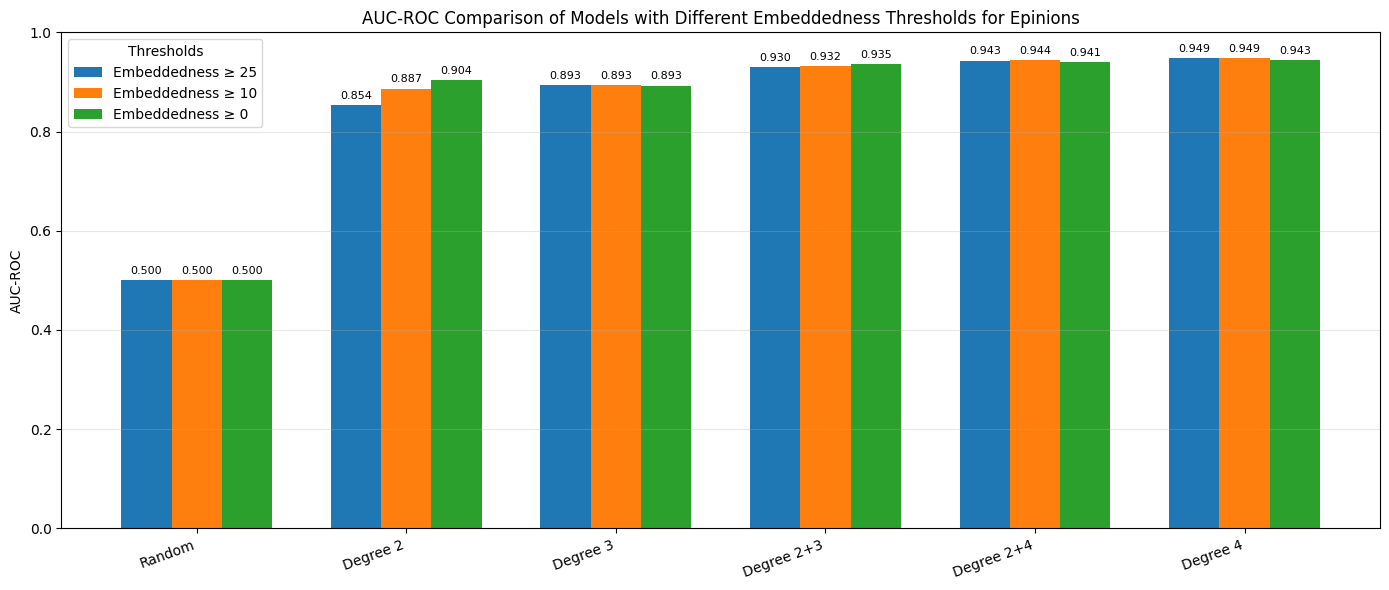

In [42]:
import matplotlib.pyplot as plt
import numpy as np

def sacar_auc(resumen, thr):
    valor = resumen[thr]
    
    # Caso normal: (acc, auc)
    if isinstance(valor, tuple) and len(valor) == 2:
        return valor[1]
    
    # Si por alguna razón viene como un único valor
    if isinstance(valor, tuple) and len(valor) == 1:
        return valor[0]
    
    # Si viene directamente como número
    return valor

auc_25 = [
    0.5,
    sacar_auc(resumen_wiki2, 25),
    sacar_auc(resumen_wiki3, 25),
    sacar_auc(resumen_wiki23, 25),
    sacar_auc(resumen_wiki24, 25),
    sacar_auc(resumen_wiki4, 25)
]

auc_10 = [
    0.5,
    sacar_auc(resumen_wiki2, 10),
    sacar_auc(resumen_wiki3, 10),
    sacar_auc(resumen_wiki23, 10),
    sacar_auc(resumen_wiki24, 10),
    sacar_auc(resumen_wiki4, 10)
]

auc_0 = [
    0.5,
    sacar_auc(resumen_wiki2, 0),
    sacar_auc(resumen_wiki3, 0),
    sacar_auc(resumen_wiki23, 0),
    sacar_auc(resumen_wiki24, 0),
    sacar_auc(resumen_wiki4, 0)
]

grupos = [
     'Random',
    'Degree 2',
    'Degree 3',
    'Degree 2+3',
    'Degree 2+4',
    'Degree 4'
]

x = np.arange(len(grupos))
width = 0.24

fig, ax = plt.subplots(figsize=(14, 6))

bars1 = ax.bar(x - width, auc_25, width, label='Embeddedness ≥ 25')
bars2 = ax.bar(x,         auc_10, width, label='Embeddedness ≥ 10')
bars3 = ax.bar(x + width, auc_0,  width, label='Embeddedness ≥ 0')

ax.set_ylabel('AUC-ROC')
ax.set_title('AUC-ROC Comparison of Models with Different Embeddedness Thresholds for Epinions')
ax.set_xticks(x)
ax.set_xticklabels(grupos, rotation=20, ha='right')
ax.set_ylim(0, 1)
ax.legend(title='Thresholds')
ax.grid(axis='y', alpha=0.3)

def autolabel(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f'{height:.3f}',
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha='center',
            va='bottom',
            fontsize=8
        )

autolabel(bars1)
autolabel(bars2)
autolabel(bars3)

fig.tight_layout()
plt.savefig("aucroc_comparacion_epinions.png", dpi=300, bbox_inches='tight')
plt.show()

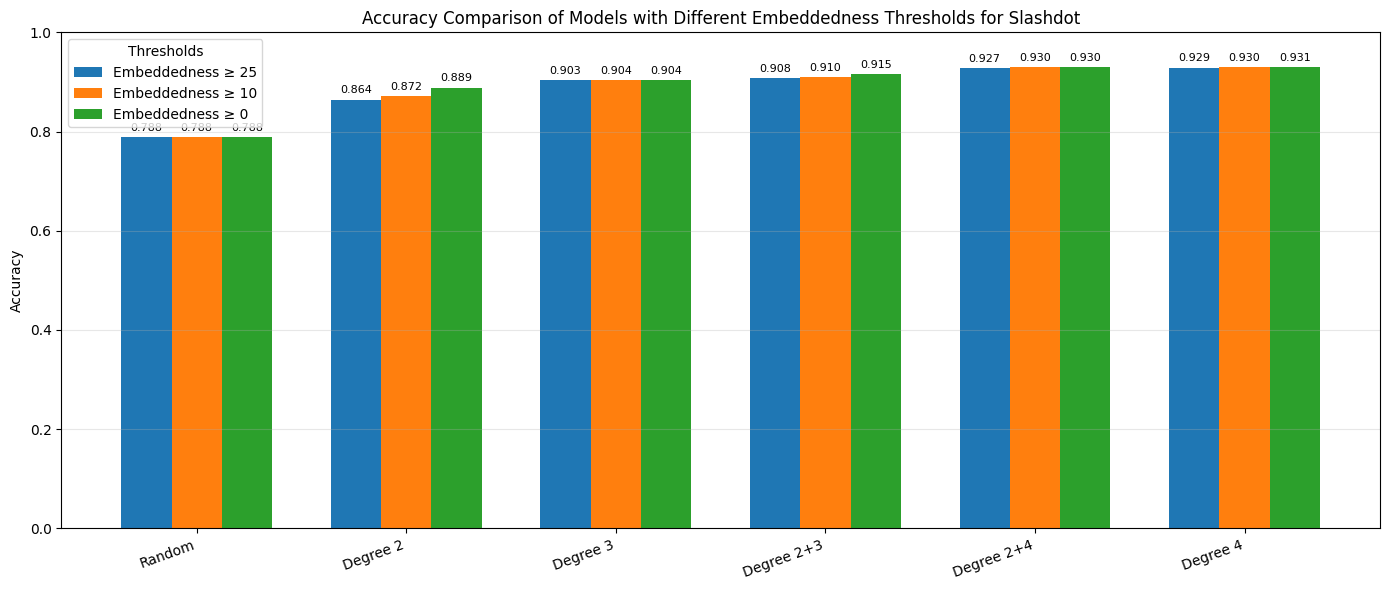

In [44]:
import matplotlib.pyplot as plt
import numpy as np

def sacar_auc(resumen, thr):
    valor = resumen[thr]
    
    # Caso normal: (acc, auc)
    if isinstance(valor, tuple) and len(valor) == 2:
        return valor[0]
    # Si viene directamente como número
    return valor

auc_25 = [
    0.788,
    sacar_auc(resumen_wiki2, 25),
    sacar_auc(resumen_wiki3, 25),
    sacar_auc(resumen_wiki23, 25),
    sacar_auc(resumen_wiki24, 25),
    sacar_auc(resumen_wiki4, 25)
]

auc_10 = [
    0.788,
    sacar_auc(resumen_wiki2, 10),
    sacar_auc(resumen_wiki3, 10),
    sacar_auc(resumen_wiki23, 10),
    sacar_auc(resumen_wiki24, 10),
    sacar_auc(resumen_wiki4, 10)
]

auc_0 = [
    0.788,
    sacar_auc(resumen_wiki2, 0),
    sacar_auc(resumen_wiki3, 0),
    sacar_auc(resumen_wiki23, 0),
    sacar_auc(resumen_wiki24, 0),
    sacar_auc(resumen_wiki4, 0)
]

grupos = [
     'Random',
    'Degree 2',
    'Degree 3',
    'Degree 2+3',
    'Degree 2+4',
    'Degree 4'
   
]

x = np.arange(len(grupos))
width = 0.24

fig, ax = plt.subplots(figsize=(14, 6))

bars1 = ax.bar(x - width, auc_25, width, label='Embeddedness ≥ 25')
bars2 = ax.bar(x,         auc_10, width, label='Embeddedness ≥ 10')
bars3 = ax.bar(x + width, auc_0,  width, label='Embeddedness ≥ 0')

ax.set_ylabel('Accuracy')
ax.set_title('Accuracy Comparison of Models with Different Embeddedness Thresholds for Slashdot')
ax.set_xticks(x)
ax.set_xticklabels(grupos, rotation=20, ha='right')
ax.set_ylim(0, 1)
ax.legend(title='Thresholds')
ax.grid(axis='y', alpha=0.3)

def autolabel(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f'{height:.3f}',
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha='center',
            va='bottom',
            fontsize=8
        )

autolabel(bars1)
autolabel(bars2)
autolabel(bars3)

fig.tight_layout()
plt.savefig("accuracy_comparacion_epinions.png", dpi=300, bbox_inches='tight')
plt.show()